# EDA - Cleaning - Plots 

In [30]:
import pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

path = '/Users/luanabreno/Desktop/Telco.2.0 - Project/'

df = pd.read_csv(path + 'data:raw:/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [31]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', 0).astype(float)
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [32]:
df.head() 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [33]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Creating a churn df, so we can analyze/compare patterns in clients that churn 

In [34]:
churn_clients = df[df['Churn'] == 'Yes']
churn_clients.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,1869.000000,1869.000000,1869.000000,1869.000000
mean,0.254682,17.979133,74.441332,1531.796094
std,0.435799,19.531123,24.666053,1890.822994
min,0.000000,1.000000,18.850000,18.850000
25%,0.000000,2.000000,56.150000,134.500000
50%,0.000000,10.000000,79.650000,703.550000
75%,1.000000,29.000000,94.200000,2331.300000
max,1.000000,72.000000,118.350000,8684.800000


### Clients that churn have lower tenure, higher monthly charges, less total charges

In [35]:
no_churn_clients = df[df['Churn'] == 'No']
no_churn_clients.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5174.000000,5174.000000,5174.000000,5174.000000
mean,0.128721,37.569965,61.265124,2549.911442
std,0.334923,24.113777,31.092648,2329.954215
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,15.000000,25.100000,572.900000
50%,0.000000,38.000000,64.425000,1679.525000
75%,0.000000,61.000000,88.400000,4262.850000
max,1.000000,72.000000,118.750000,8672.450000


In [36]:
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

categoricas = ['Contract', 'InternetService', 'TechSupport', 
               'PaymentMethod', 'OnlineSecurity']

for col in categoricas:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['Churn_bin'].mean().sort_values(ascending=False).round(3))


--- Contract ---
Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn_bin, dtype: float64

--- InternetService ---
InternetService
Fiber optic    0.419
DSL            0.190
No             0.074
Name: Churn_bin, dtype: float64

--- TechSupport ---
TechSupport
No                     0.416
Yes                    0.152
No internet service    0.074
Name: Churn_bin, dtype: float64

--- PaymentMethod ---
PaymentMethod
Electronic check             0.453
Mailed check                 0.191
Bank transfer (automatic)    0.167
Credit card (automatic)      0.152
Name: Churn_bin, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     0.418
Yes                    0.146
No internet service    0.074
Name: Churn_bin, dtype: float64


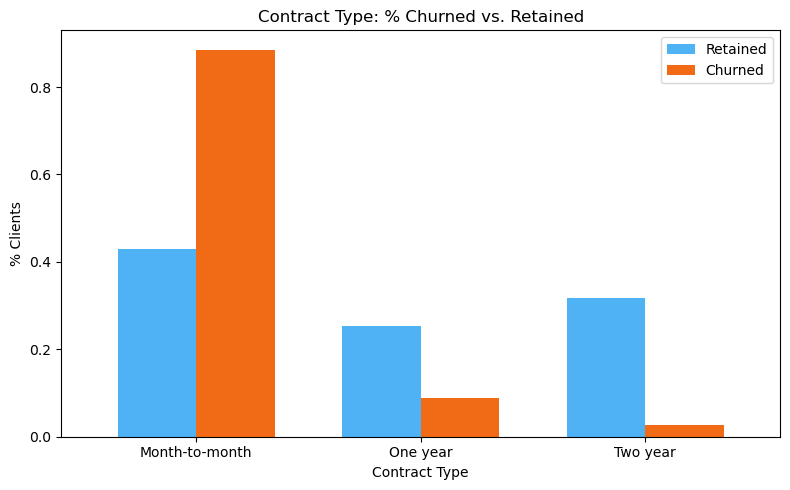

In [37]:
df.groupby('Churn')['Contract'].value_counts(normalize=True).unstack(level=0).plot(
    kind='bar',
    figsize=(8, 5),
    color=["#4eb2f5", "#f16a15"],
    width=0.7
)

plt.title('Contract Type: % Churned vs. Retained')
plt.xlabel('Contract Type')
plt.ylabel('% Clients')
plt.xticks(rotation=0)
plt.legend(['Retained', 'Churned'])
plt.tight_layout()
plt.show()

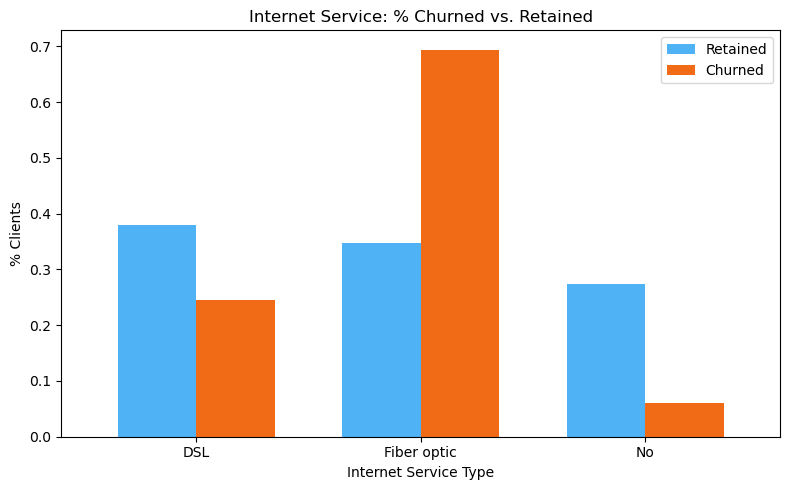

In [38]:
df.groupby('Churn')['InternetService'].value_counts(normalize=True).unstack(level=0).plot(
    kind='bar',
    figsize=(8, 5),
    color=["#4eb2f5", "#f16a15"],
    width=0.7
)

plt.title('Internet Service: % Churned vs. Retained')
plt.xlabel('Internet Service Type')
plt.ylabel('% Clients')
plt.xticks(rotation=0)
plt.legend(['Retained', 'Churned'])
plt.tight_layout()
plt.show()

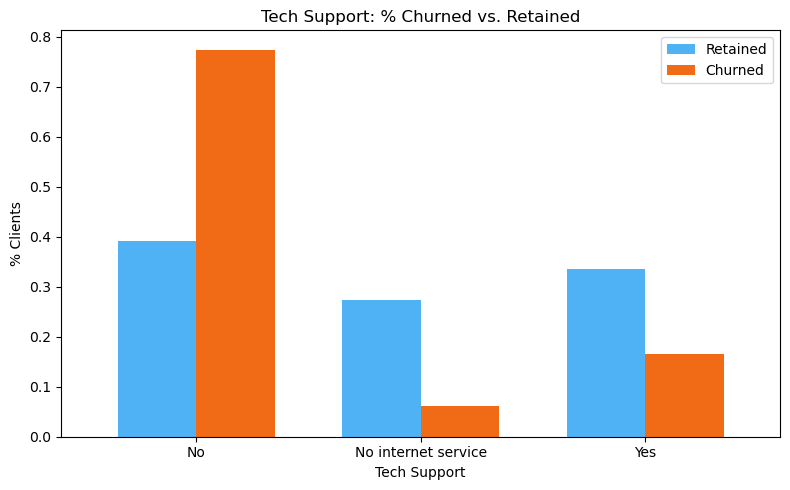

In [39]:
df.groupby('Churn')['TechSupport'].value_counts(normalize=True).unstack(level=0).plot(
    kind='bar',
    figsize=(8, 5),
    color=["#4eb2f5", "#f16a15"],
    width=0.7
)

plt.title('Tech Support: % Churned vs. Retained')
plt.xlabel('Tech Support')
plt.ylabel('% Clients')
plt.xticks(rotation=0)
plt.legend(['Retained', 'Churned'])
plt.tight_layout()
plt.show()

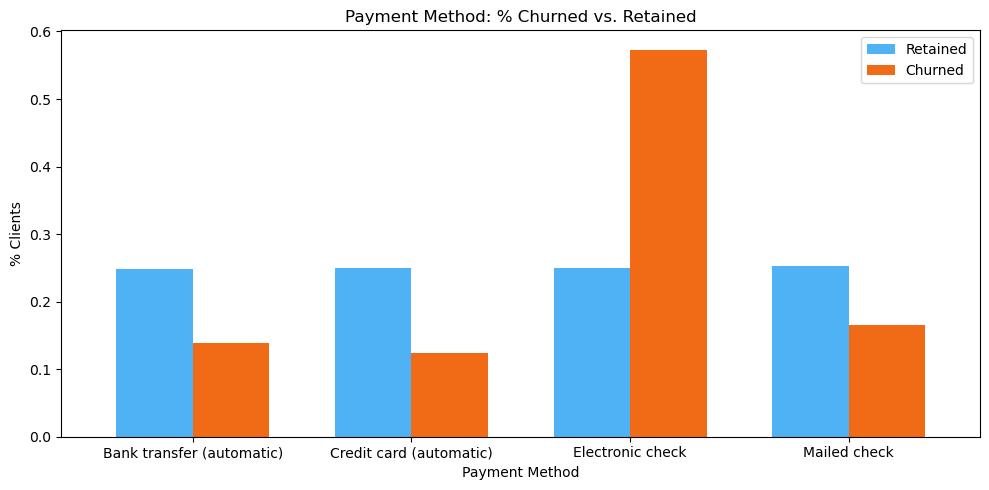

In [40]:
df.groupby('Churn')['PaymentMethod'].value_counts(normalize=True).unstack(level=0).plot(
    kind='bar',
    figsize=(10, 5),
    color=["#4eb2f5", "#f16a15"],
    width=0.7
)

plt.title('Payment Method: % Churned vs. Retained')
plt.xlabel('Payment Method')
plt.ylabel('% Clients')
plt.xticks(rotation=0)
plt.legend(['Retained', 'Churned'])
plt.tight_layout()
plt.show()

In [41]:
churn_clients[churn_clients['SeniorCitizen'] == 1]['TechSupport'].value_counts(normalize=True)

TechSupport
No                     0.882353
Yes                    0.107143
No internet service    0.010504
Name: proportion, dtype: float64

## Churn clients usually have: 
- Month-to-month contract type 
    * Push benefits or discounts to annual contracts
- No Tech Support
    * Investing in Tech Support can save us money in the long run
    * Give free Tech Support to Senior Citizens (88% of the senior citizens that churn don't have T.S)
- Higher monthly charges
- Electronic Check payment 
    * Push automatic transfers (lower churn rate)
    * Facilitate manual payments method 

### Let's add a new column for high risk customers

In [51]:
# Critério por pontuação — cada fator vale 1 ponto
df['risk_score'] = (
    (df['Contract'] == 'Month-to-month').astype(int) +
    (df['TechSupport'] == 'No').astype(int) +
    (df['PaymentMethod'] == 'Electronic check').astype(int) +
    (df['InternetService'] == 'Fiber optic').astype(int) +
    (df['tenure'] < 12).astype(int)
)

# Segmento por pontuação
df['risk_segment'] = pd.cut(
    df['risk_score'],
    bins=[-1, 1, 3, 5],
    labels=['Healthy', 'Medium Risk', 'High Risk']
)

print(df.groupby('risk_segment', observed=True).agg(
    clientes=('Churn_bin', 'count'),
    churn_rate=('Churn_bin', lambda x: f"{x.mean()*100:.1f}%"),
    MRR=('MonthlyCharges', lambda x: f"${x.sum():,.0f}")
))

              clientes churn_rate       MRR
risk_segment                               
Healthy           2753       4.8%  $147,279
Medium Risk       2650      27.1%  $178,295
High Risk         1640      62.2%  $130,543


In [58]:
print(df[df['risk_segment'] == 'High Risk']['MonthlyCharges'].mean())
# High Risk customers have an average MRR of $79.59 
df.groupby('Churn_bin')['risk_segment'].value_counts()


79.59939024390243


Churn_bin  risk_segment
0          Healthy         2621
           Medium Risk     1933
           High Risk        620
1          High Risk       1020
           Medium Risk      717
           Healthy          132
Name: count, dtype: int64

In [59]:
df.to_parquet(path + '/data_processed/churn_clean.parquet', index=False)